# 🍔 دفتر البداية السريعة - فهم مشروع التنقيب عن بيانات المطاعم

هذا الدفتر مخصص لك لكي تفهم فكرة المشروع **بسرعة وبعملي**، حتى بدون تحميل ملفات البيانات الكبيرة (التي حجمها 1.2 جيجابايت). سنستخدم عينة صغيرة من البيانات موجودة فعلاً داخل المشروع لنرى كيف تعمل كل خطوة.

---

## 🎯 ما هو فكرة المشروع باختصار؟

المشروع عبارة عن **تحليل لملايين التعليقات على تطبيق Yelp** (شبيه بـ Google Maps للمطاعم) لاستخراج معلومات مفيدة تساعد الناس في اختيار المطعم المناسب:

| الخطوة | ماذا تعمل؟ | مثال من الحياة الواقعية |
|--------|------------|--------------------------|
| **Step 1** | استخراج **المواضيع** الأكثر كلامًا عنها الناس في تعليقاتهم | أجد أن أكثر المواضيع تكرارًا هي: سرعة الخدمة، طعم الطعام، النظافة، الأسعار... |
| **Step 2** | بناء **خريطة مطابقة المأكولات** (مثال: الإيطالية تشبه البيتزا، واليابانية تشبه السوشي...) | أعرف أن شخص يحب البيتزا غالباً ما سيعجبته المطاعم الإيطالية |
| **Step 3** | اكتشاف **أشهر الأطباق** في كل نوع مطبخ (أمريكي، هندي، صيني...) | أعرف أن الأطباق الشعبية في المطبخ الأمريكي هي البرغر والدجاج والجبن والـ برغر... |
| **Step 4** | **ترتيب الأطباق** من حيث الشعبية + التقييم | أعرف أن طبق "سكالوب" نادر لكن له تقييم عالي، وطبق "أرز" شعبي جداً لكن تقييمه متوسط |
| **Step 5** | **توصية بمطاعم** مخصصة لطبق معين | أريد أفضل مطعم برغر؟ أعطيك قائمة بأعلى التقييمات في الأطباق دي |


In [1]:
# ====== الخطوة 0: إعداد البيئة (شغل هذه الخلية الأولى دائماً) ======
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re

sns.set_style('whitegrid')
%matplotlib inline
print('✅ تم تجهيز البيئة بنجاح!')

✅ تم تجهيز البيئة بنجاح!


---
## 💾 تحميل عينة البيانات (تجريبية - موجودة فعلاً في المشروع)

سنستخدم ملف `sample_data.json` الموجود في مجلد step1 به مجموعة صغيرة من التعليقات الحقيقية لنرى كل خطوة عملياً.

In [2]:
sample_path = 'step1/sample_data.json'

records = []
with open(sample_path, 'r', encoding='utf-8') as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        try:
            records.append(json.loads(line))
        except Exception:
            pass

print(f'📊 عدد التعليقات في العينة: {len(records)} تعليقات\n')
df = pd.DataFrame(records)
print('🔍 هيكل البيانات:')
display(df.head() if hasattr(df, 'head') else df[:3])
print('\n📋 الأعمدة المتوفرة:', list(df.columns))

📊 عدد التعليقات في العينة: 500 تعليقات

🔍 هيكل البيانات:


,votes,user_id,review_id,stars,date,text,type,business_id
0,"{'funny': 0, 'useful': 2, 'cool': 1}",Xqd0DzHaiyRqVH3WRG7hzg,15SdjuK7DmYqUAj6rjGowg,5,2007-05-17,dr. goldberg offers everything i look for in a...,review,vcNAWiLM4dR7D2nwwJ7nCA
1,"{'funny': 0, 'useful': 2, 'cool': 0}",H1kH6QZV7Le4zqTRNxoZow,RF6UnRTtG7tWMcrO2GEoAg,2,2010-03-22,"Unfortunately, the frustration of being Dr. Go...",review,vcNAWiLM4dR7D2nwwJ7nCA
2,"{'funny': 0, 'useful': 1, 'cool': 1}",zvJCcrpm2yOZrxKffwGQLA,-TsVN230RCkLYKBeLsuz7A,4,2012-02-14,Dr. Goldberg has been my doctor for years and ...,review,vcNAWiLM4dR7D2nwwJ7nCA
3,"{'funny': 0, 'useful': 0, 'cool': 0}",KBLW4wJA_fwoWmMhiHRVOA,dNocEAyUucjT371NNND41Q,4,2012-03-02,Been going to Dr. Goldberg for over 10 years. ...,review,vcNAWiLM4dR7D2nwwJ7nCA
4,"{'funny': 0, 'useful': 2, 'cool': 1}",zvJCcrpm2yOZrxKffwGQLA,ebcN2aqmNUuYNoyvQErgnA,4,2012-05-15,Got a letter in the mail last week that said D...,review,vcNAWiLM4dR7D2nwwJ7nCA



📋 الأعمدة المتوفرة: ['votes', 'user_id', 'review_id', 'stars', 'date', 'text', 'type', 'business_id']


---
## 1️⃣ تجربة Step 1: أين نركز الناس في تعليقاتهم؟ (تحليل التصنيفات + الكلمات)

نفهم أولاً كيف يقيّم الناس المطاعم (من نجمة لـ 5 نجوم).

C:\Users\HP\AppData\Local\Temp\ipykernel_2064\663062935.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=ratings.index.astype(str), y=ratings.values, palette=colors)
C:\Users\HP\AppData\Local\Temp\ipykernel_2064\663062935.py:12: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


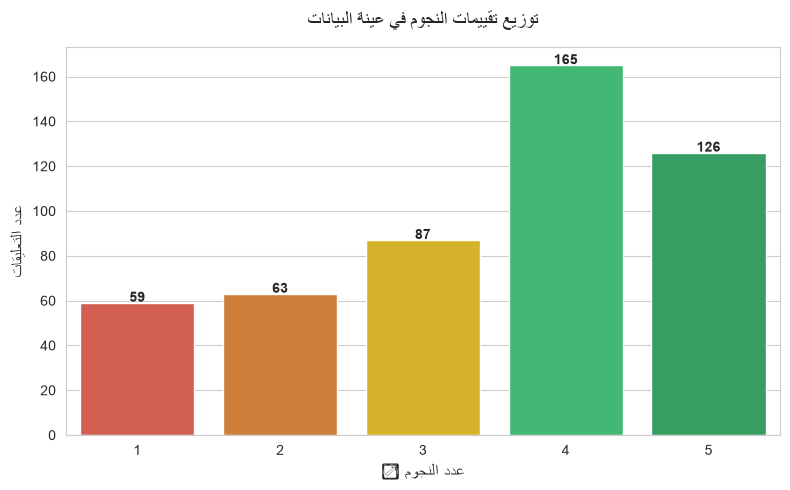

📈 متوسط التقييم العام في العينة: ⭐ 3.47 من 5


In [3]:
# 1.1 توزيع التقييمات (النجوم) - يعكس مدى رضا الناس
ratings = df['stars'].value_counts().sort_index()

plt.figure(figsize=(8, 5))
colors = ['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71', '#27ae60']
ax = sns.barplot(x=ratings.index.astype(str), y=ratings.values, palette=colors)
plt.title('توزيع تقييمات النجوم في عينة البيانات', fontsize=14, pad=15)
plt.xlabel('عدد النجوم ⭐', fontsize=12)
plt.ylabel('عدد التعليقات', fontsize=12)
for i, v in enumerate(ratings.values):
    ax.text(i, v + 0.5, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

avg = df['stars'].mean()
print(f'📈 متوسط التقييم العام في العينة: ⭐ {avg:.2f} من 5')

C:\Users\HP\AppData\Local\Temp\ipykernel_2064\1722623588.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(c1), y=list(w1), ax=ax1, palette='Greens_r')
C:\Users\HP\AppData\Local\Temp\ipykernel_2064\1722623588.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(c2), y=list(w2), ax=ax2, palette='Reds_r')
C:\Users\HP\AppData\Local\Temp\ipykernel_2064\1722623588.py:40: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\HP\AppData\Local\Temp\ipykernel_2064\1722623588.py:40: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\HP\AppData\Local\Programs\Python\Python31

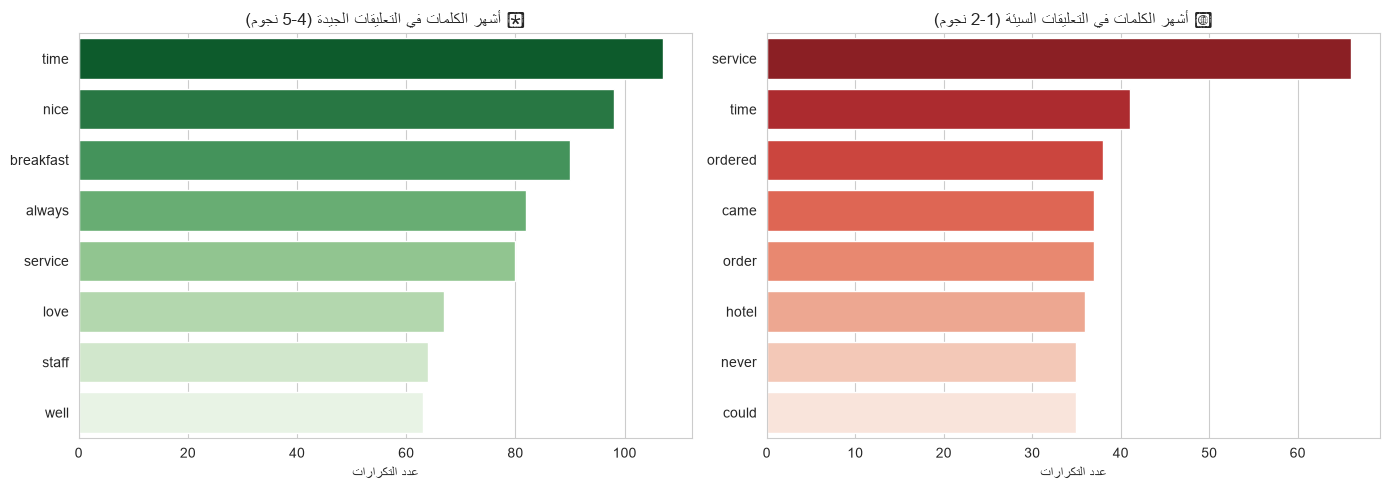

✅ ملاحظة: هذا النوع من التحليل هو أساس نموذج LDA في Step 1 لاستخراج المواضيع الرئيسية.


In [4]:
# 1.2 أبرز الكلمات في التعليقات الإيجابية vs السلبية
import nltk
from nltk.corpus import stopwords

try:
    stop_words = set(stopwords.words('english'))
except LookupError:
    nltk.download('stopwords', quiet=True)
    stop_words = set(stopwords.words('english'))

extra_ignore = {'food', 'place', 'get', 'one', 'two', 'would', 'also', 'like', 'good', 'great', 'back', 'really'}
stop_words.update(extra_ignore)

def top_words(texts, n=10):
    words = []
    for t in texts:
        for w in re.findall(r'[a-zA-Z]{3,}', t.lower()):
            if w not in stop_words:
                words.append(w)
    return Counter(words).most_common(n)

good_reviews = df[df['stars'] >= 4]['text'].values
bad_reviews = df[df['stars'] <= 2]['text'].values

good_top = top_words(good_reviews, 8)
bad_top = top_words(bad_reviews, 8)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

w1, c1 = zip(*good_top)
sns.barplot(x=list(c1), y=list(w1), ax=ax1, palette='Greens_r')
ax1.set_title('🟢 أشهر الكلمات في التعليقات الجيدة (4-5 نجوم)', fontsize=12)
ax1.set_xlabel('عدد التكرارات')

w2, c2 = zip(*bad_top)
sns.barplot(x=list(c2), y=list(w2), ax=ax2, palette='Reds_r')
ax2.set_title('🔴 أشهر الكلمات في التعليقات السيئة (1-2 نجوم)', fontsize=12)
ax2.set_xlabel('عدد التكرارات')

plt.tight_layout()
plt.show()

print('✅ ملاحظة: هذا النوع من التحليل هو أساس نموذج LDA في Step 1 لاستخراج المواضيع الرئيسية.')

---
## 4️⃣ تجربة Step 4: أشهر الأطباق + متوسط تقييمها

المشروع في الخطوة الرابعة يبحث عن كل طبق معين في التعليقات ويحسب كم مرّة ذُكر + إيه متوسط تقييم التعليقات اللي ذكرت فيه.

,dish,mentions,avg_rating,sample_review
0,Rice,117,3.35 ⭐,Good truck stop dining at the right price. We love coming here on the weekends when we don't feel like cooking....
1,Chicken,60,3.42 ⭐,Pretty good dinner with a nice selection of food. Open 24 hours and provide nice service. I usually go here after a night of partying. My favorite dish is the Fried Chicken Eggs Benedict....
2,Coffee,50,3.54 ⭐,"One of my favorite truck stop diners with solid food and friendly, quick service. My god, those desserts are huge! I can't imagine eating that giant cream puff. All the food we had was delicious and I love how they leav..."
3,Cheese,38,3.66 ⭐,"Don't have time and/or cute outfits for Madison but want an alternative to Cracker Barrel? This is your stop. I started with the chicken dumpling soup. Simply divine, so much as to seriously tempt my veg accomplice. Chee..."
4,Soup,34,3.65 ⭐,"Don't have time and/or cute outfits for Madison but want an alternative to Cracker Barrel? This is your stop. I started with the chicken dumpling soup. Simply divine, so much as to seriously tempt my veg accomplice. Chee..."
5,Salad,32,3.81 ⭐,"Nice simple homey diner. Very friendly staff, huge family friendly menu, salad bar. If you are on the road this beats the same old options...."
6,Sandwich,28,3.54 ⭐,"A really lovely surprise on a rather horrific family road trip. We were greeted at the door, the waitress was a peach, and the nice man who filled water/helped out was the sweetest guy ever. The food is also great if yo..."
7,Bread,26,3.77 ⭐,"i rarely give five star reviews but for what this restaurant is, it's pretty perfect. i've only eaten breakfast here (twice in the last three weeks) and the eggs are cooked perfectly, the sourdough toast is made in the ..."
8,Beer,25,3.24 ⭐,"Went last Friday to try the famous fish fry. Arrived at 5:50pm and was quoted a 25-30 minute wait, which I found acceptable. We were not called until 55 minutes later, and this only happened when I brought my two young..."
9,Steak,20,3.40 ⭐,hands down one of the best breakfasts my wife and i have had. stopped in here based on the positive reviews from fellow yelpers and was sure glad i did. this is a good sized diner at a truck stop. the first thing that ...


C:\Users\HP\AppData\Local\Temp\ipykernel_2064\601440209.py:39: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) Arial.
  fig.tight_layout()
C:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


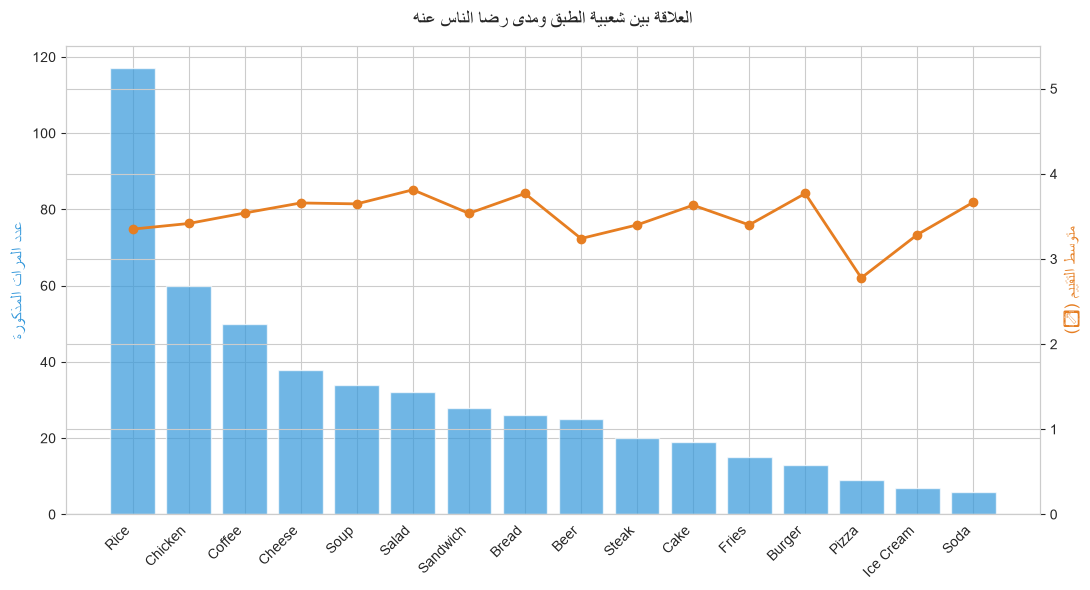

In [5]:
# قائمة بأشهر أطباق المطبخ الأمريكي (بناءً على ملفات المشروع في Step 4)
dishes_sample = ['burger', 'chicken', 'cheese', 'rice', 'fries', 'steak', 'pizza', 'salad',
                 'sandwich', 'soup', 'bread', 'cake', 'ice cream', 'coffee', 'beer', 'soda']

def dish_stats(dish_name, reviews_df):
    mentions = reviews_df[reviews_df['text'].str.contains(dish_name, case=False, na=False)]
    if len(mentions) == 0:
        return None
    return {
        'dish': dish_name.title(),
        'mentions': len(mentions),
        'avg_rating': mentions['stars'].mean(),
        'sample_review': mentions.iloc[0]['text'][:220] + '...'
    }

results = []
for d in dishes_sample:
    s = dish_stats(d, df)
    if s:
        results.append(s)

dish_df = pd.DataFrame(results).sort_values('mentions', ascending=False).reset_index(drop=True)
display(dish_df.style.format({'avg_rating': '{:.2f} ⭐'}))

# الرسم البياني
fig, ax1 = plt.subplots(figsize=(11, 6))
x = range(len(dish_df))
ax1.bar(x, dish_df['mentions'], color='#3498db', alpha=0.7, label='عدد المرات المذكورة')
ax1.set_xticks(x)
ax1.set_xticklabels(dish_df['dish'], rotation=45, ha='right')
ax1.set_ylabel('عدد المرات المذكورة', color='#3498db', fontsize=12)

ax2 = ax1.twinx()
ax2.plot(x, dish_df['avg_rating'], color='#e67e22', marker='o', linewidth=2, label='متوسط التقييم')
ax2.set_ylim(0, 5.5)
ax2.set_ylabel('متوسط التقييم (⭐)', color='#e67e22', fontsize=12)

plt.title('العلاقة بين شعبية الطبق ومدى رضا الناس عنه', fontsize=14, pad=15)
fig.tight_layout()
plt.show()

---
## 5️⃣ تجربة Step 5: أوصِلي بأفضل مطعم لطبق معين

مثال: أنا عايز أجرب برغر 🥩، أي مطعم فيه أفضل تقييم في التعليقات اللي بتذكّر كلمة "burger"؟

In [6]:
target_dish = 'burger'

mentions_df = df[df['text'].str.contains(target_dish, case=False, na=False)].copy()
print(f'🍔 عدد التعليقات اللي ذكرت فيها "{target_dish}": {len(mentions_df)}')

if len(mentions_df) > 0:
    # لو كان عندنا business_name هنستخدمه، هنا في العينة ال business_id بس؛ نعرضه كرمز
    restaurant_stats = mentions_df.groupby('business_id').agg(
        reviews_with_dish=('stars', 'count'),
        avg_rating_for_dish=('stars', 'mean'),
        sample_comments=('text', lambda x: ' | '.join(x.astype(str).str[:80]))
    ).sort_values(['avg_rating_for_dish', 'reviews_with_dish'], ascending=False).reset_index()

    print('\n🏆 قائمة المطاعم (مقترحة حسب التقييم):')
    display(restaurant_stats.head(10).style.format({'avg_rating_for_dish': '{:.2f} ⭐'}))
else:
    print(f'لم يتم العثور على تعليقات تذكر {target_dish} في هذه العينة الصغيرة.')

🍔 عدد التعليقات اللي ذكرت فيها "burger": 13

🏆 قائمة المطاعم (مقترحة حسب التقييم):


,business_id,reviews_with_dish,avg_rating_for_dish,sample_comments
0,LRKJF43s9-3jG9Lgx4zODg,5,4.40 ⭐,"Californians are all about the In-N-Out, where you can get your burger animal st | Next to Chick-Fil-A, Culver's is my fav fast food chain. Rarely is a snowboardi | Go-to meal: cheddar butter burger, fried cheese curds, and flavor of the day cus | My meaty goodness...why isn't Culvers a nationwide chain? This bacon cheese bur | Everything was great except for the burgers they are greasy and very charred com"
1,rdAdANPNOcvUtoFgcaY9KA,2,4.00 ⭐,"We ate there several weeks back so the details are a bit thin, but I do recall t | are favorite fish fry in madison area get there before 530 if you dont want to a"
2,x7pStpT09Tdc8d7oRU0Tmw,1,4.00 ⭐,I have mixed emotions. I love coming here because it has locations of store tha
3,HaBkx5PwvbBpQ2iNCgHnVQ,3,3.67 ⭐,"May be one of Middleton's best kept secrets... I had run past Paul's on numerous | Great neighborhood bar! There definitely isn't anything 'special' on tap here, b | Average place. Average food. Fried stuff and fried burgers. Loud. Rowdy crow"
4,xbJ9tdGbcVJIUkNgHSCwZQ,1,3.00 ⭐,The Hody is a pretty solid local bar in Middleton that often has great live musi
5,1tkeiIa-daD8LbM6mHm_9A,1,1.00 ⭐,"Smoke-filled bathrooms, gross food, even if the burgers are a buck. Expensive b"


---
## 🧪 تحليل المشاعر (Sentiment Analysis) - جزء من Step 4

نفس فكرة الـ VADER اللي المشروع بيستخدمها: نقسم التعليق إلى إيجابي / سلبي / محايد.

In [7]:
try:
    from nltk.sentiment.vader import SentimentIntensityAnalyzer
    nltk.download('vader_lexicon', quiet=True)
    sia = SentimentIntensityAnalyzer()
except Exception as e:
    print(f'ℹ️  VADER غير متاح حالياً: {e}')
    sia = None

if sia:
    sample_texts = df.sample(min(5, len(df)))['text'].values
    for i, txt in enumerate(sample_texts, 1):
        scores = sia.polarity_scores(txt)
        mood = '🟢 إيجابي' if scores['compound'] > 0.2 else ('🔴 سلبي' if scores['compound'] < -0.2 else '🟡 محايد')
        print(f'{i}. ({mood} | overall={scores["compound"]:+.2f})  {txt[:110]}...\n')
else:
    print('يمكنك تثبيت nltk وتحميل vader_lexicon لرؤية هذا الجزء.')

1. (🟢 إيجابي | overall=+0.96)  Chin's is my go-to "fast food" stop in my neighborhood. I fell in love with Chin's when I was living across th...

2. (🟢 إيجابي | overall=+0.97)  I can't stand to sit here and read these horrible reviews. 
When my son was receiving treatments for spine/ br...

3. (🟢 إيجابي | overall=+0.61)  Definitely a place I could frequent...nice and open and live blues music every Tuesday night.   Be sure to che...

4. (🟢 إيجابي | overall=+0.42)  I was there on Monday December 30, 2013.  And I will NEVER be back again.  I waited nearly ten minutes for a p...

5. (🟢 إيجابي | overall=+0.97)  This is the second time I stayed here with my b/f.  This time I was less impressed.  The staff as usual was fa...



---
## ✅ خلاصة فهمك الآن للمشروع:

| # | الخطوة | ماذا فهِمنا الآن عملياً؟ |
|---|--------|------------------------------|
| 1 | استخراج المواضيع | نحسب الكلمات المتكررة ونقسم التعليقات إلى مجاميع (مثل: تجربة خدمة جيدة، مشاكل في الانتظار...) باستخدام نموذج LDA |
| 2 | خريطة المطابقة بين المأكولات | نجمع تعليقات كل نوع مطبخ ونشوف كم الكلمات المشتركة بينهم (بيتزا و إيطالية = تشابه عالي جداً) |
| 3 | اكتشاف أطباق المطبخ | نستخدم نماذج كثيرة الكلمات + Word2Vec نطلع كل أنواع الأطباق غير اللي نعرفها |
| 4 | ترتيب الأطباق | لكل طبق نحسب عدد المرات اللي اتذكر + متوسط التقييم + تحليل المشاعر (سعيد / حزين) |
| 5 | توصية المطاعم | بدي أفضل مطعم برغر؟ بخلي التعليقات اللي فيها كلمة برغر بس وآخذ متوسطها وأرتب |

🚀 **جاهز للتعمق؟** افتح أي دفتر من مجلدات `step1/` حتى `step5/` وشوف النتائج الكاملة على بيانات Yelp الأصلية لو كانت متوفرة.